# Firmware y Control de bajo nivel del brazo

**Enfoque:** firmware de bajo nivel para **joysticks, ADC, servomotores y PWM**.

Este documento actualiza la propuesta de control del brazo de 5 GDL y se concentra en la interfaz entre el firmware y el hardware:

- lectura de entradas analógicas de los joysticks;
- conversión de las lecturas ADC en órdenes de movimiento;
- generación de señales para los servomotores;
- mapeo de ángulos a pulsos;
- inicialización y uso de la librería `sapi_servo`;
- conexionado de la EDU-CIAA-NXP;

> **Alcance:** esta versión se concentra en el control de bajo nivel. La cinemática y la lógica de alto nivel quedan fuera del núcleo de este documento.


## 1. Actualización de la estrategia de control

El brazo tiene **5 grados de libertad**, pero para el prototipo se parte de **3 entradas analógicas disponibles para el control directo**.

### Propuesta actual

| Pin | Función |
|---|---|
| ADC CH1 | Joystick 1 — eje X |
| ADC CH2 | Joystick 1 — eje Y |
| ADC CH3 | Joystick 2 — eje X |
| GPIO digital | Abrir/Cerrar pinza |
| SERVO(0-8) | Servos |


## 2. Entradas analógicas: ADC de la EDU-CIAA-NXP

La librería `sapi_adc` utiliza un mapa lógico de entradas analógicas. En la configuración de la EDU-CIAA-NXP aparecen:

```c
CH1 = 0
CH2 = 1
CH3 = 2
CH4 = 3
```

Sin embargo, para esta versión del proyecto se consideran **3 entradas analógicas de uso directo**:

```text
CH1 → ADC_CH1 → ADC0_1
CH2 → ADC_CH2 → ADC0_2
CH3 → ADC_CH3 → ADC0_3
```

### Lectura básica

```c
adcInit(ADC_ENABLE);

uint16_t x = adcRead(CH1);
uint16_t y = adcRead(CH2);
uint16_t z = adcRead(CH3);
```

La lectura devuelve un valor digital correspondiente a la tensión aplicada al canal analógico.

## 3. Joysticks y acondicionamiento de la lectura

Cada joystick analógico entrega dos señales.

El punto central del joystick debe producir una tensión aproximadamente intermedia entre alimentación y GND.

Para un ADC de 10 bits, conceptualmente:

```text
0 V       → ~0
Vref/2    → ~512
Vref      → ~1023
```

El valor exacto del centro debe determinarse experimentalmente porque el joystick no necesariamente entrega exactamente 512.

### Zona muerta

Para evitar que pequeñas variaciones alrededor del centro produzcan movimiento:

```c
#define CENTRO_ADC      512
#define ZONA_MUERTA     30

if(valor > CENTRO_ADC - ZONA_MUERTA &&
   valor < CENTRO_ADC + ZONA_MUERTA)
{
    comando = 0;
}
```

### De posición absoluta a velocidad

Para el control manual resulta conveniente interpretar el joystick como una orden de **velocidad angular**:

```text
Joystick hacia la izquierda
        ↓
velocidad negativa
        ↓
ángulo disminuye progresivamente
```

y:

```text
Joystick hacia la derecha
        ↓
velocidad positiva
        ↓
ángulo aumenta progresivamente
```

Al soltar el joystick:

```text
joystick → centro
        ↓
zona muerta
        ↓
velocidad = 0
        ↓
servo conserva su posición
```

Esto evita que el servo salte inmediatamente a una posición absoluta determinada por el joystick.

## 4. Servomotores

Los servomotores utilizados en este tipo de brazo normalmente reciben una señal periódica de control tipo PWM.

La información importante no es solamente el porcentaje de duty cycle, sino principalmente el **ancho del pulso**.

Conceptualmente:

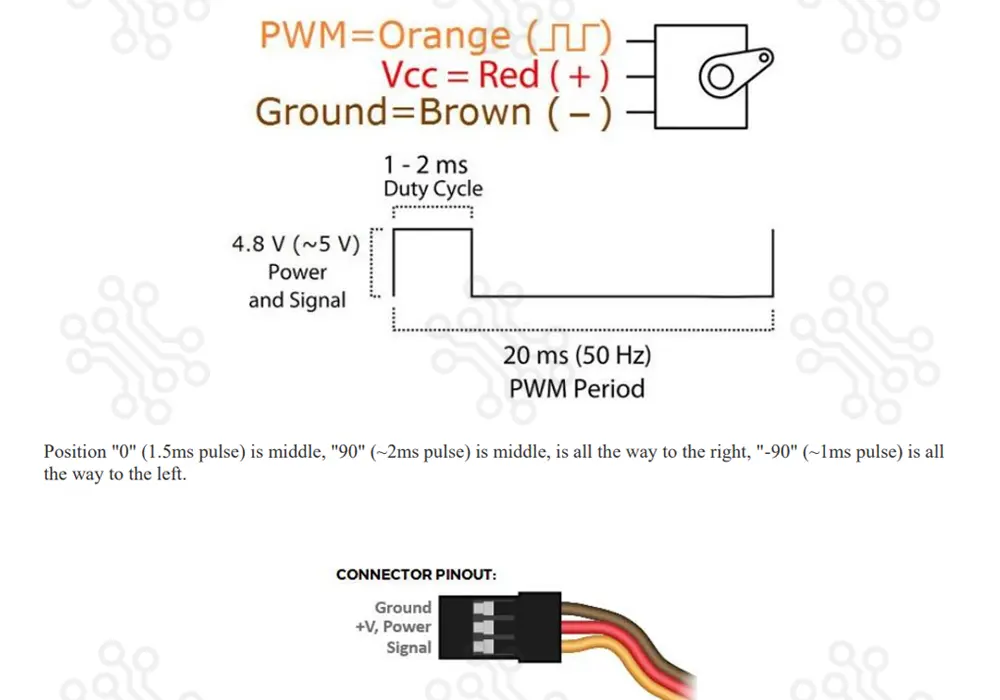

Un valor de referencia habitual es aproximadamente:

```text
0°   → ~1000 µs(1ms)
90°  → ~1500 µs(1.5 ms)
180° → ~2000 µs(2 ms)
```

**Estos valores deben tratarse como valores de referencia,** el rango real debe verificarse para evitar daños.

La frecuencia de actualización utilizada por la librería de servos se encuentra en el orden de los **50 Hz**, es decir, un periodo de aproximadamente:

```text
T = 20 ms
```



## 5. Cómo `sapi_servo` genera la señal

La librería proporcionada abstrae la generación de los pulsos mediante:

```c
servoWrite(servoNumber, angle);
```

El programa no necesita configurar manualmente el ancho del pulso cada vez que mueve un servo.

La cadena conceptual es:

```text
ángulo deseado
     ↓
servoWrite()
     ↓
conversión ángulo → microsegundos
     ↓
temporizadores
     ↓
señal de servo
     ↓
pin físico de la EDU-CIAA
     ↓
servo
```

La librería declara:

```c
uint32_t valueToMicroseconds(uint8_t);
```

por lo que internamente existe una conversión desde el valor angular hacia un ancho de pulso.

También declara:

```c
void servoInitTimers(void);
bool_t servoAttach(servoMap_t servoNumber);
bool_t servoDetach(servoMap_t servoNumber);
```

Esto muestra que la generación de las señales está basada en temporizadores y que existe una capa de abstracción que permite asociar un servo a una salida.

### Restricción importante de la librería

El encabezado `sapi_servo.h` indica explícitamente que la implementación utiliza:

```text
Timer 1
Timer 2
Timer 3
```

para generar las señales de servo.

Por lo tanto, mientras se utilice esta implementación, esos temporizadores **no deben considerarse disponibles para otras funciones que entren en conflicto con la librería de servos**.


## 6. Salidas físicas de los servos

| Servo lógico | Salida física de EDU-CIAA-NXP |
|---|---|
| SERVO0 | T_FIL1 |
| SERVO1 | T_COL0 |
| SERVO2 | T_FIL2 |
| SERVO3 | T_FIL3 |
| SERVO4 | GPIO8 |
| SERVO5 | LCD1 |
| SERVO6 | LCD2 |
| SERVO7 | LCD3 |
| SERVO8 | GPIO2 |


Para el brazo se utilizan las siguientes.

### Asignación mecánica

| Servo | Articulación propuesta | Pin EDU CIAA |
|---|---|---|
| SERVO0 | Base | T_FIL1 (36) |
| SERVO1 | Hombro | T_COL0 (39) |
| SERVO2 | Codo | T_FIL2 (37) |
| SERVO3 | Muñeca | T_FIL3 (35) |
| SERVO4 | Pinza | GPIO8 (40) |

La asignación puede cambiarse en software si se termina utilizando otra correspondencia.

In [ ]:
/* Inicialización mínima de los 5 servos */

#include "sapi.h"

int main(void)
{
    boardConfig();

    /* Inicializa el subsistema de servos */
    servoConfig(SERVO0, SERVO_ENABLE);

    /* Habilita las salidas que vamos a utilizar */
    servoConfig(SERVO0, SERVO_ENABLE_OUTPUT);
    servoConfig(SERVO1, SERVO_ENABLE_OUTPUT);
    servoConfig(SERVO2, SERVO_ENABLE_OUTPUT);
    servoConfig(SERVO3, SERVO_ENABLE_OUTPUT);
    servoConfig(SERVO4, SERVO_ENABLE_OUTPUT);

    /* Posiciones iniciales */
    servoWrite(SERVO0, 90);
    servoWrite(SERVO1, 90);
    servoWrite(SERVO2, 90);
    servoWrite(SERVO3, 90);
    servoWrite(SERVO4, 0);

    while(1) {
        /* Control del brazo */
    }

    return 0;
}


## 7. Qué ocurre cuando se ejecuta `servoWrite()`

Por ejemplo:

```c
servoWrite(SERVO2, 90);
```

puede interpretarse conceptualmente como:

```text
    SERVO2
      ↓
seleccionar salida asociada
      ↓
 ángulo = 90°
      ↓
convertir 90° a ancho de pulso
      ↓
configurar/actualizar comparación del temporizador
      ↓
generar pulso periódico
      ↓
  pin T_FIL2
      ↓
servo del codo
```

No es necesario llamar a `servoWrite()` a la frecuencia de 50 Hz desde el `main`. La librería se encarga de mantener la generación periódica de la señal mediante los temporizadores.

Por eso diferenciar:

- **frecuencia de actualización del comando:** cada cuánto decidimos cambiar el ángulo;
- **frecuencia de la señal del servo:** frecuencia con la que la librería genera los pulsos.


## 8. Frecuencias y tiempos del firmware

Hay que distinguir tres escalas temporales:

### A. Señal de los servos

La librería trabaja con una señal periódica del orden de:

```text
50 Hz
T ≈ 20 ms
```

Esta generación queda a cargo de los temporizadores internos de `sapi_servo`.

### B. Lectura de los joysticks

No es necesario leer el ADC a 50 Hz exactamente. Una frecuencia del orden de algunas decenas de Hz puede ser suficiente para el control manual.

Por ejemplo:

```text
lectura ADC → cada 10–20 ms
```

### C. Actualización del ángulo

La orden de movimiento puede actualizarse cada 10–20 ms, aplicando un incremento pequeño:

```text
joystick → comando
            ↓
       cada 20 ms
            ↓
       +1° / -1°
```

Esto permite obtener un movimiento progresivo.

>Conviene usar delays? por el bloqueo de ejecución de otras tareas. 


In [ ]:
/* Una estructura del superloop podria ser */

#include "sapi.h"

int main(void)
{
    boardConfig();

    /* ADC */
    adcInit(ADC_ENABLE);

    /* Servos */
    servoConfig(SERVO0, SERVO_ENABLE);
    servoConfig(SERVO0, SERVO_ENABLE_OUTPUT);
    servoConfig(SERVO1, SERVO_ENABLE_OUTPUT);
    servoConfig(SERVO2, SERVO_ENABLE_OUTPUT);
    servoConfig(SERVO3, SERVO_ENABLE_OUTPUT);
    servoConfig(SERVO4, SERVO_ENABLE_OUTPUT);

    /* Posición segura/inicial */
    servoWrite(SERVO0, 90);
    servoWrite(SERVO1, 90);
    servoWrite(SERVO2, 90);
    servoWrite(SERVO3, 90);
    servoWrite(SERVO4, 0);

    delay_t controlTimer;
    delayConfig(&controlTimer, 20);

    while(1) {

        if(delayRead(&controlTimer)) {

            /* 1. Leer ADC */
            uint16_t j1x = adcRead(CH1);
            uint16_t j1y = adcRead(CH2);
            uint16_t j2x = adcRead(CH3);

            /* 2. Filtrar / aplicar zona muerta */
            /* 3. Convertir a comando */
            /* 4. Actualizar ángulos */
            /* 5. Escribir los servos */

            /*
             * servoWrite(SERVO0, angleBase);
             * servoWrite(SERVO1, angleShoulder);
             * servoWrite(SERVO2, angleElbow);
             * servoWrite(SERVO3, angleWrist);
             * servoWrite(SERVO4, angleGripper);
             */
        }
    }

    return 0;
}
